# INVERTER CIRCUIT 32nm bulk CMOS

> Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

> https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction/tree/main/CMOS

## Obs

I'm using simu_0/treated_data dataset in this analysis

Joined_data.csv: contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

Treated_data.csv: contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algotithms usa o joined_data e depois gera o treated_data;

No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "../../../../data/raw/CMOS/32nm/NOT/simu_0/treated_data.txt"
plots_dir = "../../../../figures/CMOS/32nm/NOT/01_data_exploration/"
df = pd.read_csv(path, index_col=0)

Renaming the column 'tensao' to 'voltage' to maintain the English standard

In [3]:
df = df.rename(columns={
    'temper' : 'temperature',
    'tensao' : 'voltage', 
    'pmos@varp': 'PV_pmos', 
    'nmos@var': 'PV_nmos', 
    'width_pmos':  'W PMOS', 
    'width_nmos': 'W NMOS', 
    'length_n&p': 'L',
    'iint' : 'energy'
})

In [4]:
nova_ordem = [
    'PV_nmos',
    'PV_pmos',
    'temperature',
    'voltage',
    'W NMOS',
    'W PMOS',
    'L',
    'tphl', 
    'tplh',
    'energy'
]

df = df[nova_ordem]

df

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
0,0.5166,-0.4341,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.607000e-12,8.368000e-12,-1.330000e-15
1,0.5064,-0.4523,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.424000e-12,8.791000e-12,-1.337000e-15
2,0.4909,-0.4618,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.156000e-12,9.046000e-12,-1.388000e-15
3,0.4882,-0.4667,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.111000e-12,9.161000e-12,-1.395000e-15
4,0.5275,-0.4342,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.809000e-12,8.899000e-12,-1.351000e-15
...,...,...,...,...,...,...,...,...,...,...
167995,0.5126,-0.4225,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.682000e-12,2.399000e-11,-1.790000e-15
167996,0.4847,-0.4406,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.130000e-12,2.513000e-11,-2.135000e-15
167997,0.4997,-0.4561,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.415000e-12,2.639000e-11,-1.833000e-15
167998,0.5154,-0.4417,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.738000e-12,2.516000e-11,-1.677000e-15


## Dataset

Inputs (7 total)
x = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs (3 total)
y = [tphl, tplh, energy]

Variables (10 total)

- **nmos@var**: NMOS transistor process variation
- **pmos@var**: PMOS transistor process variation
- **tphl**:	propagation delay from output High to Low
- **tplh**: propagation delay from output Low to High
- **energy**:	energy dissipated by the circuit
- **temper**: operating temperature of the circuit
- **voltage**: supply voltage (VDD)
- **width_pmos**: width W of the PMOS transistor
- **width_nmos**: width W of the NMOS transistor
- **length_n&p**: channel length L of the NMOS and PMOS transistors

Units
- **nmos@var**: Volts (V)
- **pmos@var**: Volts (V)
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **energy**:	Joules (J)
- **temper**: Celsius (°C)
- **voltage**: Volts (V)
- **width_pmos**: Meters (m)
- **width_nmos**: Meters (m)
- **length_n&p**: Meters (m)

**Checking if there're null values, how many different values in each variable and type**

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 155077 entries, 0 to 167999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PV_nmos      155077 non-null  float64
 1   PV_pmos      155077 non-null  float64
 2   temperature  155077 non-null  float64
 3   voltage      155077 non-null  float64
 4   W NMOS       155077 non-null  float64
 5   W PMOS       155077 non-null  float64
 6   L            155077 non-null  float64
 7   tphl         155077 non-null  float64
 8   tplh         155077 non-null  float64
 9   energy       155077 non-null  float64
dtypes: float64(10)
memory usage: 13.0 MB


There're only numerical variables.

In [6]:
df.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       167990, 167991, 167992, 167993, 167994, 167995, 167996, 167997, 167998,
       167999],
      dtype='int64', length=155077)

The difference between the length (155.077) and the range of indexes values (0 - 167.999) means treated_data really has been treated. There're gaps that have been taken out of the dataset.

In [7]:
df.size

1550770

155077 x 10 = 1550770 
Total number of data points in the entire table (rows x columns).

In [8]:
df.shape

(155077, 10)

Total of samples/observations: 155.077 (rows)
Total of features/attributes (Xs and Ys): 10 (columns)

In [9]:
df.nunique()

PV_nmos          513
PV_pmos          489
temperature        6
voltage            4
W NMOS             2
W PMOS             5
L                  3
tphl            8200
tplh           10430
energy         14040
dtype: int64

There aren't fixed variables values.

- **nmos@var**: Existem 513 valores diferentes
- **pmos@var**:	Existem 489 valores diferentes
- **tphl**:	Existem 8200 valores diferentes
- **tplh**:	Existem 10430 valores diferentes
- **energy**:	Existem 14040 valores diferentes
- **temper**:	Existem 6 temperaturas diferentes
- **voltage**:	Existem 4 tensões diferentes
- **width_pmos**:	Existem 5 larguras diferentes
- **width_nmos**:	Existem 2 larguras diferentes
- **length_n&p**: Existem 3 valores diferentes

In [10]:
df.describe(include="all")

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
count,155077.000000,155077.000000,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05,1.550770e+05,1.550770e+05,1.550770e+05
mean,0.509108,-0.450684,37.467033,0.750069,8.083333e-08,2.266666e-07,3.238095e-08,6.592126e-11,-6.440956e-10,-2.063419e-03
std,0.016825,0.015274,42.982289,0.111693,2.531751e-08,1.234463e-07,4.477225e-09,7.263116e-10,2.477490e-09,2.024013e-01
min,0.461300,-0.493300,-25.000000,0.600000,7.000000e-08,7.000000e-08,2.000000e-08,-3.819000e-12,-1.000000e-08,-3.342370e+01
25%,0.497800,-0.461900,0.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,9.825000e-12,7.604000e-12,-2.351000e-15
50%,0.509000,-0.450500,50.000000,0.800000,7.000000e-08,1.400000e-07,3.200000e-08,1.226000e-11,1.080000e-11,-1.657000e-15
75%,0.520200,-0.440300,75.000000,0.800000,7.000000e-08,3.500000e-07,3.200000e-08,1.476000e-11,1.874000e-11,-1.336000e-15
max,0.586100,-0.405800,100.000000,0.900000,1.400000e-07,4.200000e-07,4.000000e-08,1.018000e-08,2.631000e-10,2.933300e+01


- count: number of non-null values (155.077)
- mean: average value
- std: stadard deviation (how spread out the data is)
- min/max: range
- 25%, 50%, 75%: percentiles, where 50% is median

In [11]:
df.isnull().sum()

PV_nmos        0
PV_pmos        0
temperature    0
voltage        0
W NMOS         0
W PMOS         0
L              0
tphl           0
tplh           0
energy         0
dtype: int64

As we've seen before, there is no null values.

The dataset is composed only of quantitative (numerical) variables, there's none categorical (non-numerical) variables

#### Frequency of each item

In [12]:
df['tphl'].value_counts()

tphl
 1.001000e-08    682
 1.242000e-11    211
 1.168000e-11    210
 1.006000e-11    207
 1.197000e-11    203
                ... 
-1.428000e-13      1
 2.395000e-12      1
 9.427000e-11      1
 1.222000e-12      1
 2.159000e-12      1
Name: count, Length: 8200, dtype: int64

In [13]:
df['tplh'].value_counts()

tplh
-9.988000e-09    628
-9.987000e-09    523
-9.995000e-09    452
-9.989000e-09    350
-9.977000e-09    347
                ... 
-9.470000e-09      1
 2.714000e-11      1
 1.653000e-11      1
-9.631000e-09      1
-9.702000e-09      1
Name: count, Length: 10430, dtype: int64

In [14]:
df['energy'].value_counts()

energy
-1.556000e-15    246
-1.553000e-15    239
-1.551000e-15    237
-1.604000e-15    237
-1.550000e-15    234
                ... 
-9.819000e-16      1
-9.838000e-16      1
-9.765000e-16      1
-9.758000e-16      1
-9.884000e-16      1
Name: count, Length: 14040, dtype: int64

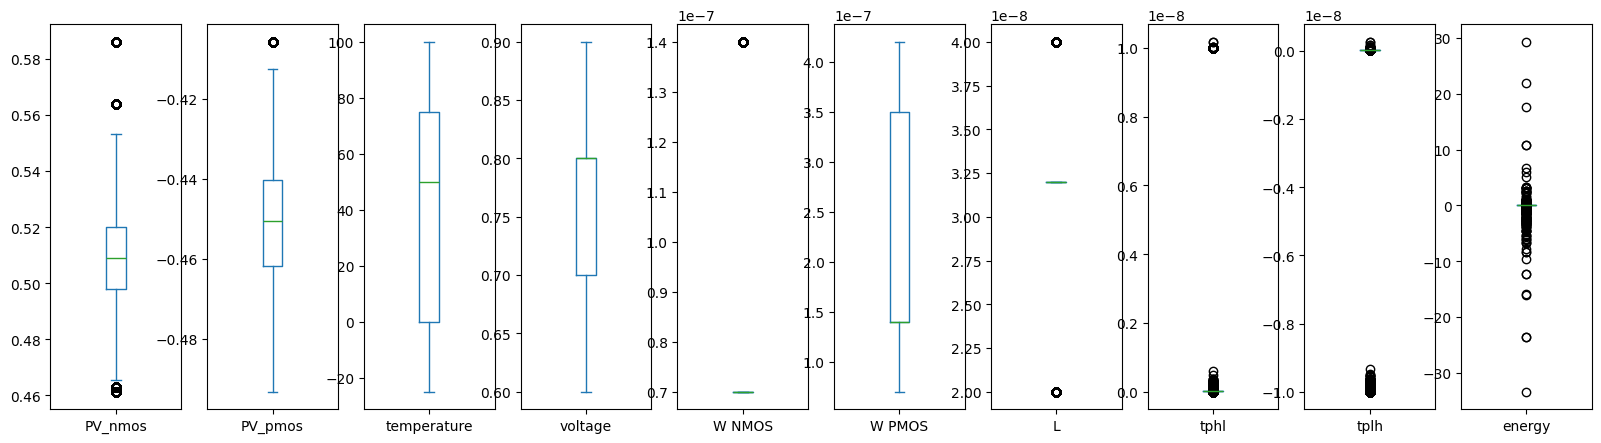

<Figure size 640x480 with 0 Axes>

In [15]:
df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

## Removing outliers

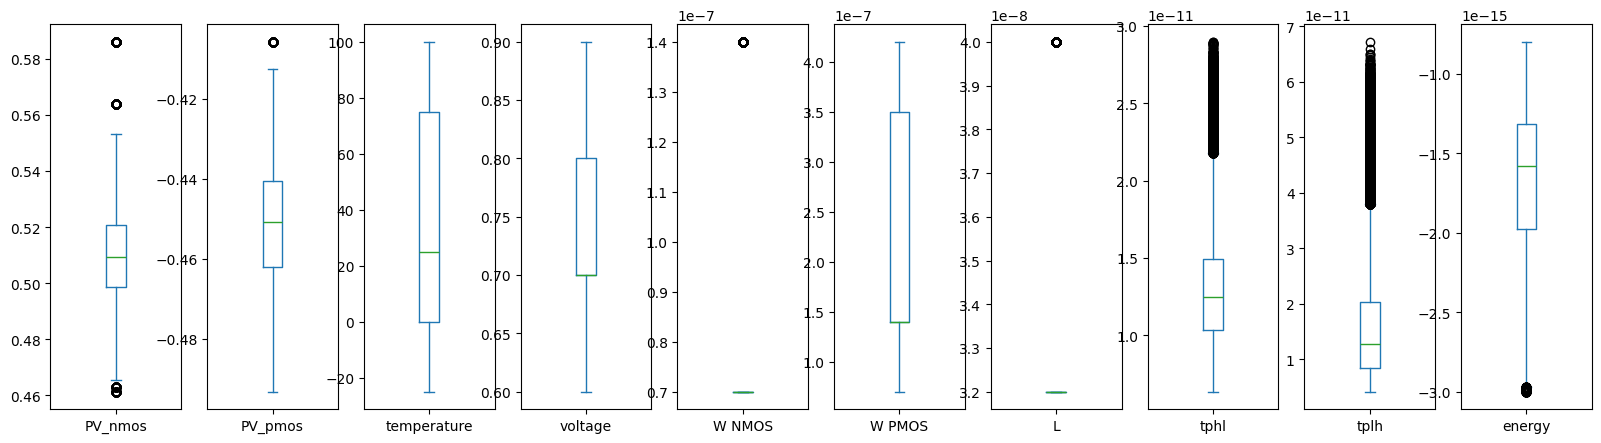

<Figure size 640x480 with 0 Axes>

In [16]:
# Gabriel's code fot removing outliers
df = df[(2e-12<=df.tphl)&(df.tphl<=2.9e-11)]
df = df[(1e-12<=df.tplh)&(df.tplh<=6.8e-11)]
df = df[(-3e-15<=df.energy)]

df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

In [17]:
df

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
0,0.5166,-0.4341,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.607000e-12,8.368000e-12,-1.330000e-15
1,0.5064,-0.4523,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.424000e-12,8.791000e-12,-1.337000e-15
2,0.4909,-0.4618,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.156000e-12,9.046000e-12,-1.388000e-15
3,0.4882,-0.4667,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.111000e-12,9.161000e-12,-1.395000e-15
4,0.5275,-0.4342,-25.0,0.6,7.000000e-08,1.400000e-07,3.200000e-08,9.809000e-12,8.899000e-12,-1.351000e-15
...,...,...,...,...,...,...,...,...,...,...
167995,0.5126,-0.4225,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.682000e-12,2.399000e-11,-1.790000e-15
167996,0.4847,-0.4406,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.130000e-12,2.513000e-11,-2.135000e-15
167997,0.4997,-0.4561,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.415000e-12,2.639000e-11,-1.833000e-15
167998,0.5154,-0.4417,50.0,0.9,7.000000e-08,7.000000e-08,3.200000e-08,9.738000e-12,2.516000e-11,-1.677000e-15


In [18]:
df.describe()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
count,127771.000000,127771.000000,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05
mean,0.509723,-0.451149,32.301735,0.749356,7.819810e-08,2.164066e-07,3.349893e-08,1.291333e-11,1.577203e-11,-1.685973e-15
std,0.016645,0.015210,41.687904,0.107559,2.250916e-08,1.204728e-07,3.121656e-09,3.385645e-12,9.954472e-12,4.944592e-16
min,0.461300,-0.493300,-25.000000,0.600000,7.000000e-08,7.000000e-08,3.200000e-08,6.351000e-12,4.125000e-12,-3.000000e-15
25%,0.498500,-0.462200,0.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.036000e-11,8.464000e-12,-1.979000e-15
50%,0.509500,-0.450900,25.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.248000e-11,1.277000e-11,-1.579000e-15
75%,0.520700,-0.440600,75.000000,0.800000,7.000000e-08,3.500000e-07,3.200000e-08,1.492000e-11,2.024000e-11,-1.317000e-15
max,0.586100,-0.405800,100.000000,0.900000,1.400000e-07,4.200000e-07,4.000000e-08,2.898000e-11,6.720000e-11,-7.993000e-16


## Exploratory Data Plots

Inputs (7 total)
x = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs (3 total)
y = [tphl, tplh, energy]

Variables (10 total)

- **nmos@var**: NMOS transistor process variation
- **pmos@var**: PMOS transistor process variation
- **tphl**:	propagation delay from output High to Low
- **tplh**: propagation delay from output Low to High
- **energy**:	energy dissipated by the circuit
- **temper**: operating temperature of the circuit
- **voltage**: supply voltage (VDD)
- **width_pmos**: width W of the PMOS transistor
- **width_nmos**: width W of the NMOS transistor
- **length_n&p**: channel length L of the NMOS and PMOS transistors

Units
- **nmos@var**: Volts (V)
- **pmos@var**: Volts (V)
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **energy**:
- **temper**: Celsius (°C)
- **voltage**: Volts (V)
- **width_pmos**: Meters (m)
- **width_nmos**: Meters (m)
- **length_n&p**: Meters (m)

There aren't fixed variables values.

- **nmos@var**: 513 
- **pmos@var**:	489 different values
- **tphl**: 8200 different values
- **tplh**: 10430 different values
- **energy**: 14040 different values
- **temper**: 6 different values
- **voltage**: 4 different values
- **width_pmos**: 5 different values
- **width_nmos**: 2 different values
- **length_n&p**: 3 different values

In [19]:
df.describe(include="all")

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
count,127771.000000,127771.000000,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05,1.277710e+05
mean,0.509723,-0.451149,32.301735,0.749356,7.819810e-08,2.164066e-07,3.349893e-08,1.291333e-11,1.577203e-11,-1.685973e-15
std,0.016645,0.015210,41.687904,0.107559,2.250916e-08,1.204728e-07,3.121656e-09,3.385645e-12,9.954472e-12,4.944592e-16
min,0.461300,-0.493300,-25.000000,0.600000,7.000000e-08,7.000000e-08,3.200000e-08,6.351000e-12,4.125000e-12,-3.000000e-15
25%,0.498500,-0.462200,0.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.036000e-11,8.464000e-12,-1.979000e-15
50%,0.509500,-0.450900,25.000000,0.700000,7.000000e-08,1.400000e-07,3.200000e-08,1.248000e-11,1.277000e-11,-1.579000e-15
75%,0.520700,-0.440600,75.000000,0.800000,7.000000e-08,3.500000e-07,3.200000e-08,1.492000e-11,2.024000e-11,-1.317000e-15
max,0.586100,-0.405800,100.000000,0.900000,1.400000e-07,4.200000e-07,4.000000e-08,2.898000e-11,6.720000e-11,-7.993000e-16


In [20]:
output_vars = ['tphl', 'tplh', 'energy']

variance_results = df[output_vars].var()
std_dev_results = df[output_vars].std()

eda_summary = pd.DataFrame({
    'Variance': variance_results,
    'Standard Deviation': std_dev_results
})

print(eda_summary)

            Variance  Standard Deviation
tphl    1.146259e-23        3.385645e-12
tplh    9.909152e-23        9.954472e-12
energy  2.444899e-31        4.944592e-16


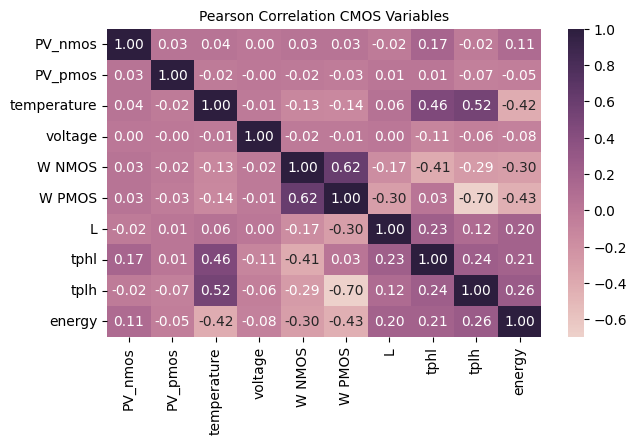

In [21]:
# Correlation
plt.figure(figsize=(7, 4))
ax = sns.heatmap(df.corr(method='pearson', numeric_only=True), 
                annot=True, fmt=".2f",
                cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Pearson Correlation CMOS Variables', fontsize=10)
ax=ax
plt.savefig(f"{plots_dir}/cmos_correlation.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [22]:
df.corr()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L,tphl,tplh,energy
PV_nmos,1.000000,0.034806,0.038418,0.002917,0.032598,0.034796,-0.022720,0.174995,-0.022641,0.112036
PV_pmos,0.034806,1.000000,-0.023705,-0.001645,-0.019272,-0.031196,0.014684,0.014604,-0.070825,-0.053504
temperature,0.038418,-0.023705,1.000000,-0.007740,-0.130118,-0.139460,0.058240,0.461049,0.520156,-0.422117
voltage,0.002917,-0.001645,-0.007740,1.000000,-0.015177,-0.010176,0.003433,-0.112415,-0.055632,-0.076660
W NMOS,0.032598,-0.019272,-0.130118,-0.015177,1.000000,0.615506,-0.174886,-0.410514,-0.288699,-0.300066
W PMOS,0.034796,-0.031196,-0.139460,-0.010176,0.615506,1.000000,-0.304539,0.028063,-0.696719,-0.434837
L,-0.022720,0.014684,0.058240,0.003433,-0.174886,-0.304539,1.000000,0.232621,0.123447,0.201189
tphl,0.174995,0.014604,0.461049,-0.112415,-0.410514,0.028063,0.232621,1.000000,0.238986,0.209867
tplh,-0.022641,-0.070825,0.520156,-0.055632,-0.288699,-0.696719,0.123447,0.238986,1.000000,0.264389
energy,0.112036,-0.053504,-0.422117,-0.076660,-0.300066,-0.434837,0.201189,0.209867,0.264389,1.000000


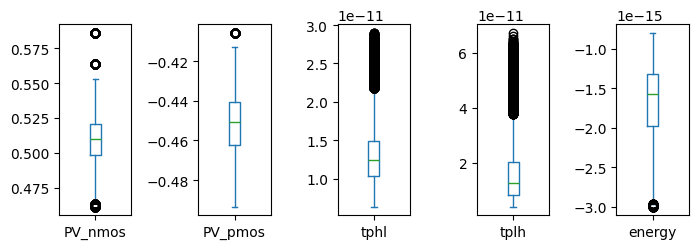

In [23]:
variables = ['temperature', 'voltage', 'W PMOS', 'W NMOS', 'L']
cols = [c for c in df.columns if 'length' not in c.lower() and c not in variables]
axes = df[cols].plot(kind='box', figsize=(7, 2.6), subplots=True, layout=(1, len(cols)))

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_boxplot.png", bbox_inches='tight')
plt.show()
plt.close()

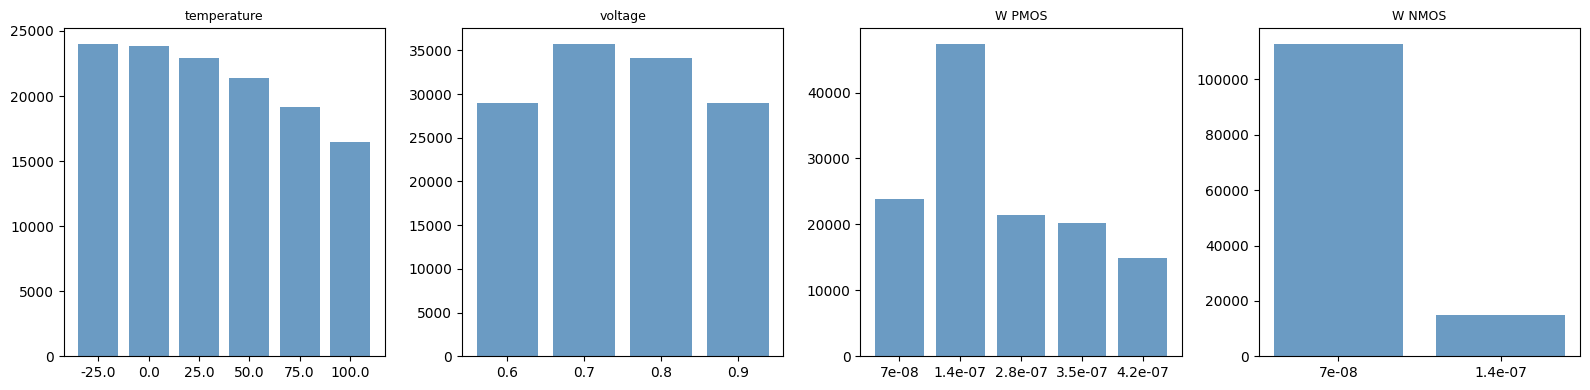

In [24]:
cols = ['temperature', 'voltage', 'W PMOS', 'W NMOS']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

for i, col in enumerate(cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_count_plot.png")
plt.show()
plt.close()

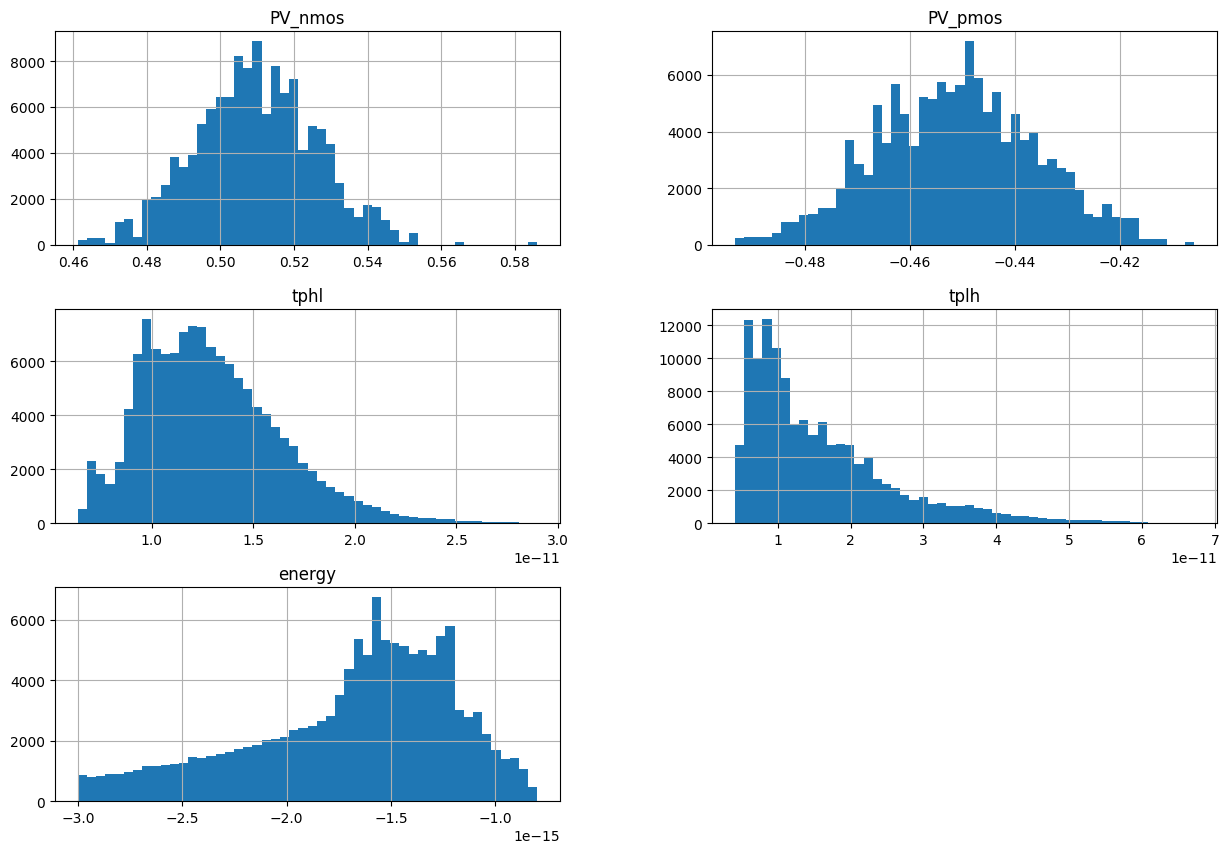

In [25]:
df[['PV_nmos', 'PV_pmos', 'tphl', 'tplh', 'energy']].hist(
    bins=50, 
    figsize=(15, 10), 
    layout=(3, 2)
)
    
plt.savefig(f"{plots_dir}/cmos_histogram.png")
plt.show()
plt.close()

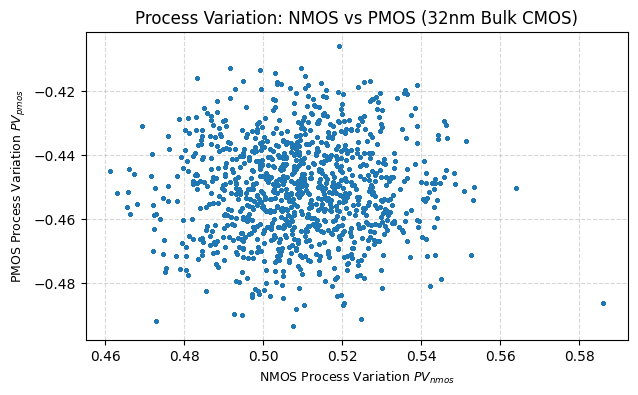

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
plt.plot('PV_nmos', 'PV_pmos', data=df, linestyle='none', marker='D', markersize=2)
plt.title('Process Variation: NMOS vs PMOS (32nm Bulk CMOS)')
plt.xlabel('NMOS Process Variation $PV_{nmos}$', fontsize=9)
plt.ylabel('PMOS Process Variation $PV_{pmos}$', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig(f"{plots_dir}/cmos_scatter_plot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Train, Validation, Test Sets & Scaling (StandardScaler)

First split: 75% training, 25% test
Secound split (train, validation):
33% of 75% ~ 25% of the original data becomes the validation set

Result:
- Train ~50%
- Validation ~25%
- Test 25%

In [27]:
X = df.drop(columns=['tphl', 'tplh', 'energy'])
y = df[['tphl', 'tplh', 'energy']]
print(X.shape)
print(y.shape)

(127771, 7)
(127771, 3)


In [28]:
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

set_config(transform_output="pandas")

seed = 23

# Test set 25%
Xtr, Xte, ytr, yte = train_test_split(X, y, random_state=seed, test_size=0.25)

# Train/Validation set - train total ~50% and validation ~25%
X_train, X_val, y_train, y_val = train_test_split(Xtr, ytr, random_state=seed, test_size=0.33)

# The model only knows the train data (fit() only on training data, never on test/validation)
scaler_x = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_sc = scaler_x.transform(X_train)
X_val_sc = scaler_x.transform(X_val)
Xte_sc = scaler_x.transform(Xte)

y_train_sc = scaler_y.transform(y_train)
y_val_sc = scaler_y.transform(y_val)
yte_sc = scaler_y.transform(yte)

print("Train set X", X_train_sc.shape)
print("Train set y", y_train_sc.shape)
print("Validation set X", X_val_sc.shape)
print("Validation set y", y_val_sc.shape)
print("Test set X", Xte_sc.shape)
print("Test set y", yte_sc.shape)

Train set X (64204, 7)
Train set y (64204, 3)
Validation set X (31624, 7)
Validation set y (31624, 3)
Test set X (31943, 7)
Test set y (31943, 3)


In [29]:
X_train.head()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L
59943,0.5031,-0.4734,-25.0,0.7,1.400000e-07,4.200000e-07,3.200000e-08
86477,0.5141,-0.4249,75.0,0.8,7.000000e-08,7.000000e-08,3.200000e-08
58699,0.5281,-0.4640,100.0,0.7,7.000000e-08,3.500000e-07,3.200000e-08
84759,0.5118,-0.4730,-25.0,0.8,7.000000e-08,1.400000e-07,3.200000e-08
53902,0.5026,-0.4438,0.0,0.7,7.000000e-08,3.500000e-07,3.200000e-08


In [30]:
X_train_sc.head()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L
59943,-0.395440,-1.466100,-1.377877,-0.461522,2.771445,1.694973,-0.483887
86477,0.266399,1.725939,1.021131,0.470434,-0.360823,-1.214869,-0.483887
58699,1.108739,-0.847437,1.620883,-0.461522,-0.360823,1.113004,-0.483887
84759,0.128014,-1.439774,-1.377877,0.470434,-0.360823,-0.632901,-0.483887
53902,-0.425524,0.482031,-0.778125,-0.461522,-0.360823,1.113004,-0.483887


### Sets Visualization


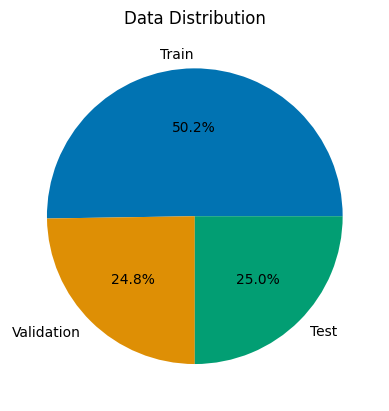

In [31]:
sizes = [len(X_train), len(X_val), len(Xte)]
labels = ['Train', 'Validation', 'Test']

colors = sns.color_palette('colorblind')[0:3]

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Data Distribution')
plt.savefig(f"{plots_dir}/cmos_split_data_distribution.png")
plt.show()
plt.close()

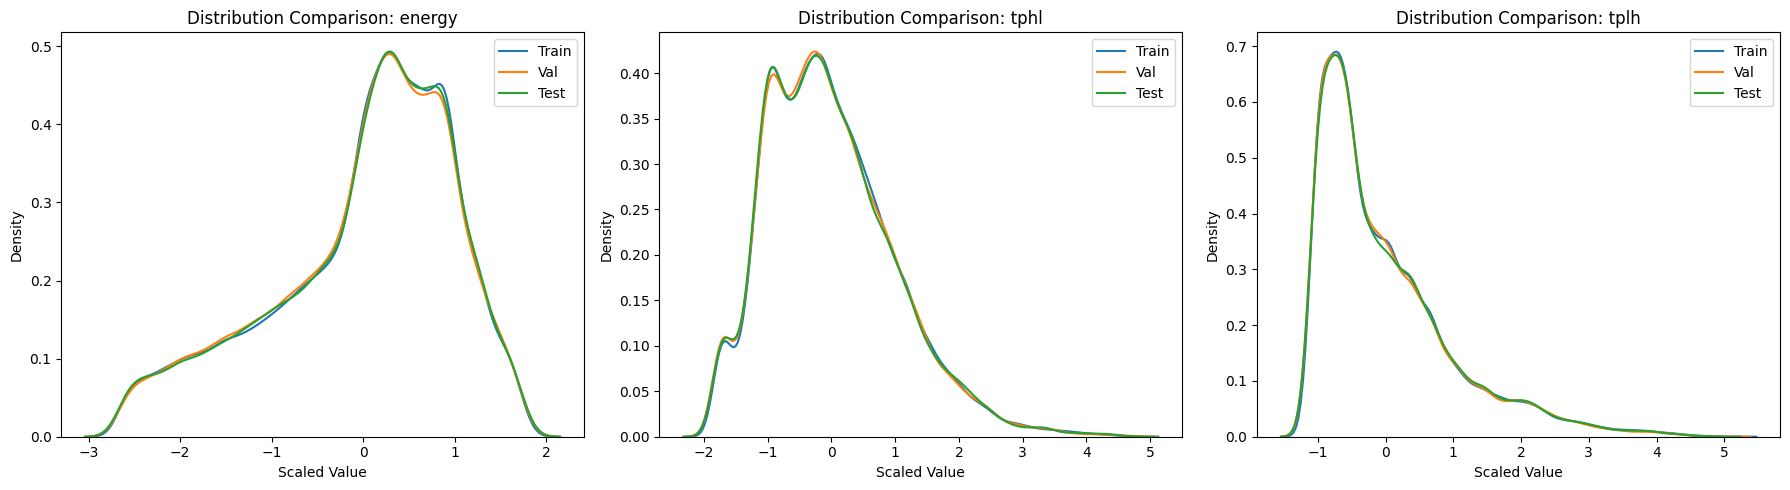

In [32]:
targets = ['energy', 'tphl', 'tplh']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    sns.kdeplot(y_train_sc[col], label='Train', ax=axes[i])
    sns.kdeplot(y_val_sc[col], label='Val', ax=axes[i])
    sns.kdeplot(yte_sc[col], label='Test', ax=axes[i])
    
    axes[i].set_title(f'Distribution Comparison: {col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_dataset_distribution_comparison.png")
plt.show()
plt.close()

In [33]:
# Salvando dados separados e scalers
X_train_sc.to_csv('../../../../data/processed/CMOS/32nm/NOT/X_train_sc.csv', index=False)
X_val_sc.to_csv('../../../../data/processed/CMOS/32nm/NOT/X_val_sc.csv', index=False)
Xte_sc.to_csv('../../../../data/processed/CMOS/32nm/NOT/X_test_sc.csv', index=False)

y_train_sc.to_csv('../../../../data/processed/CMOS/32nm/NOT/y_train_sc.csv', index=False)
y_val_sc.to_csv('../../../../data/processed/CMOS/32nm/NOT/y_val_sc.csv', index=False)
yte_sc.to_csv('../../../../data/processed/CMOS/32nm/NOT/y_test_sc.csv', index=False)

import joblib

joblib.dump(scaler_x, '../../../../data/processed/CMOS/32nm/NOT/scaler_x.pkl')
joblib.dump(scaler_y, '../../../../data/processed/CMOS/32nm/NOT/scaler_y.pkl')

['../../../../data/processed/CMOS/32nm/NOT/scaler_y.pkl']